In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

**1. Data Loading & Initial Understanding**


In [ ]:
data = pd.read_excel("/content/retail_large_dataset.xlsx")

In [ ]:
data

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


In [ ]:
data.shape

(100000, 18)

In [ ]:
data.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'product_price', 'quantity', 'discount_percentage', 'final_price',
       'payment_method', 'shipping_type', 'delivery_days', 'return_status'],
      dtype='object')

In [ ]:
data.isnull().sum()

,0
customer_id,0
age,0
gender,0
city,0
state,0
customer_segment,0
order_id,0
order_date,0
product_category,0
product_subcategory,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,2024-06-29 02:48:38.304000,30164.526720,2.501790,15.009890,64165.723382,5.505540
min,18.000000,2023-01-01 00:00:00,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,2023-09-30 00:00:00,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,2024-06-28 00:00:00,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,2025-03-30 00:00:00,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,2025-12-30 00:00:00,59998.000000,4.000000,30.000000,239980.000000,10.000000
std,13.852439,NaN,17139.679807,1.120058,8.953296,49969.280150,2.872868


In [ ]:
data.nunique()

,0
customer_id,100000
age,48
gender,2
city,10
state,9
customer_segment,3
order_id,100000
order_date,1095
product_category,6
product_subcategory,21



**3. Univariate Analysis**



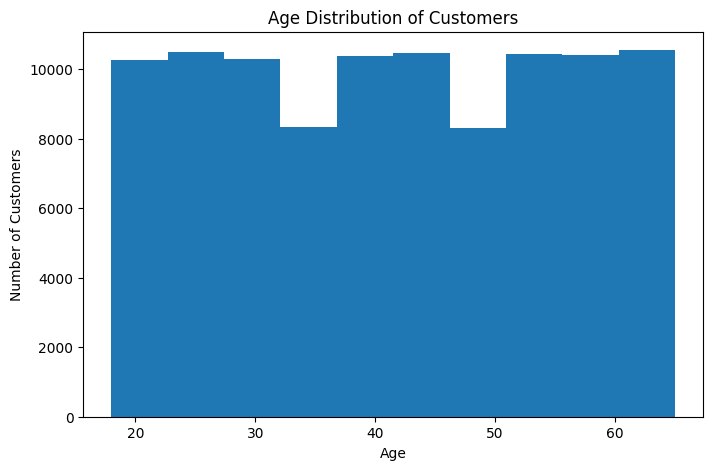

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(data['age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Age Distribution of Customers')
plt.show()

In [ ]:
gender_count = data['gender'].value_counts()

print(gender_count)

gender
Male      50111
Female    49889
Name: count, dtype: int64


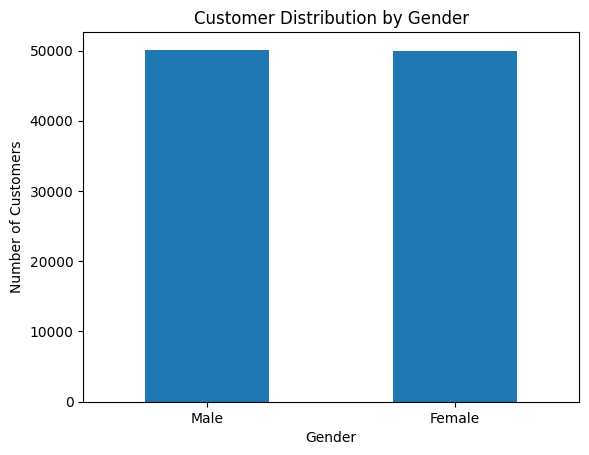

In [ ]:
gender_count.plot(kind='bar')

plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Gender')
plt.xticks(rotation=0)

plt.show()

In [ ]:
product_count = data['product_category'].value_counts()

print(product_count)

product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64


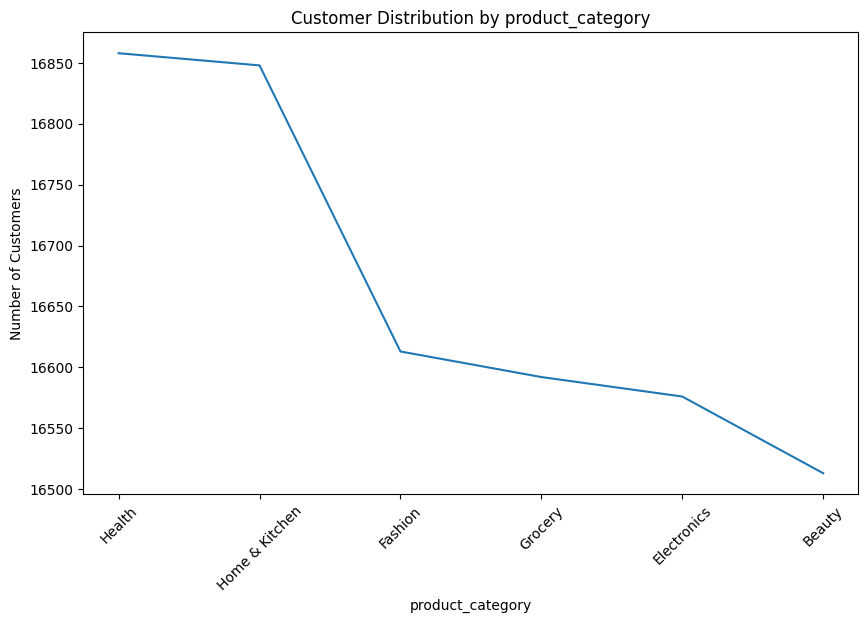

In [ ]:
plt.figure(figsize=(10,6))

product_count.plot(kind='line')

plt.xlabel('product_category')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by product_category')
plt.xticks(rotation=45)

plt.show()

**4. Bivariate Analysis**

product_category
Beauty            410.40
Electronics       407.52
Fashion           424.86
Grocery           411.20
Health            424.08
Home & Kitchen    357.00
Name: final_price, dtype: float64


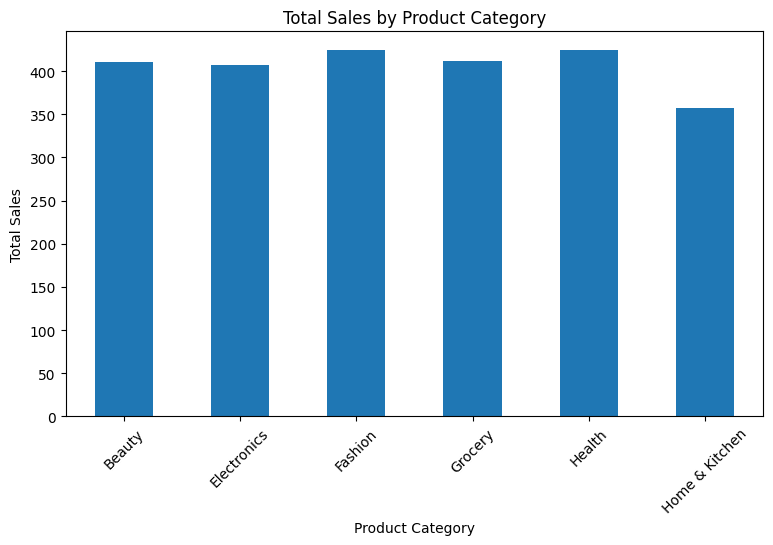

In [ ]:
category_sales = data.groupby('product_category')['final_price'].min()

print(category_sales)

plt.figure(figsize=(9,5))
category_sales.plot(kind='bar')

plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product Category')
plt.xticks(rotation=45)

plt.show()

In [ ]:
payment_aov = data.groupby('payment_method')['final_price'].count()

print(payment_aov)

payment_method
Cash on Delivery    24994
Credit Card         25307
Debit Card          24560
UPI                 25139
Name: final_price, dtype: int64


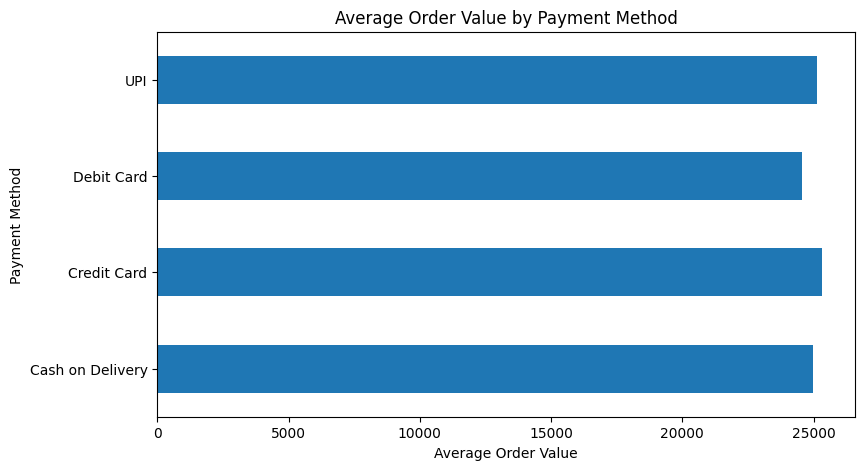

In [ ]:
plt.figure(figsize=(9,5))

payment_aov.plot(kind='barh')

plt.xlabel('Average Order Value')
plt.ylabel('Payment Method')
plt.title('Average Order Value by Payment Method')

plt.show()

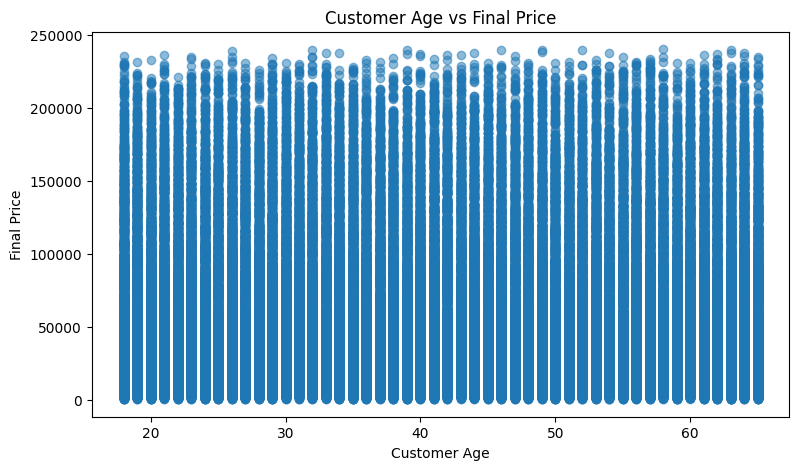

In [ ]:
plt.figure(figsize=(9,5))

plt.scatter(data['age'], data['final_price'], alpha=0.5)

plt.xlabel('Customer Age')
plt.ylabel('Final Price')
plt.title('Customer Age vs Final Price')

plt.show()

customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64


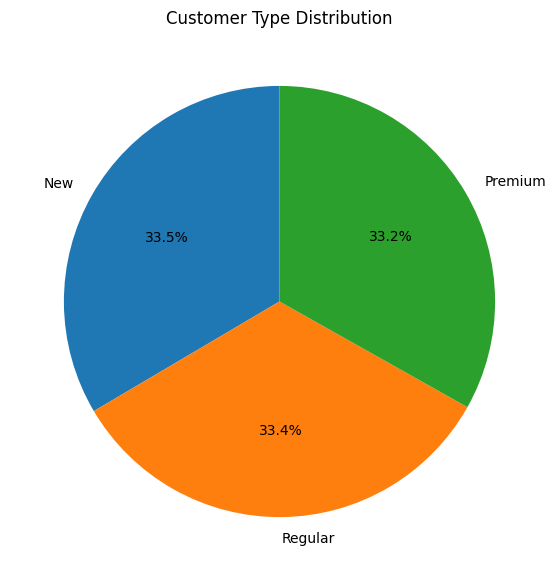

In [ ]:
customer_type_count = data['customer_segment'].value_counts()

print(customer_type_count)

plt.figure(figsize=(7,7))

plt.pie(
    customer_type_count,
    labels=customer_type_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Type Distribution')
plt.show()

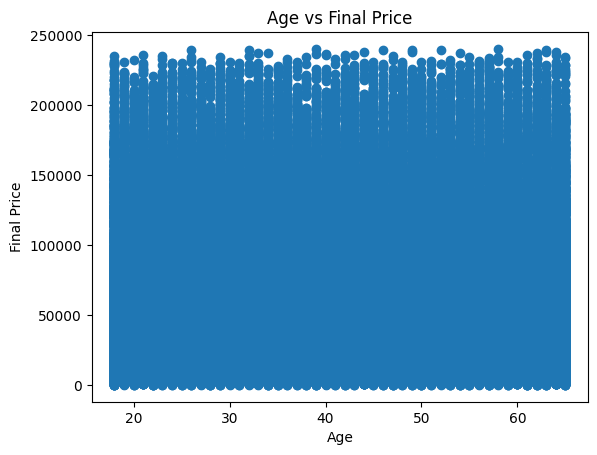

In [ ]:
plt.scatter(data['age'], data['final_price'])
plt.xlabel('Age')
plt.ylabel('Final Price')
plt.title('Age vs Final Price')
plt.show()

**5. Multivariate Analysis**

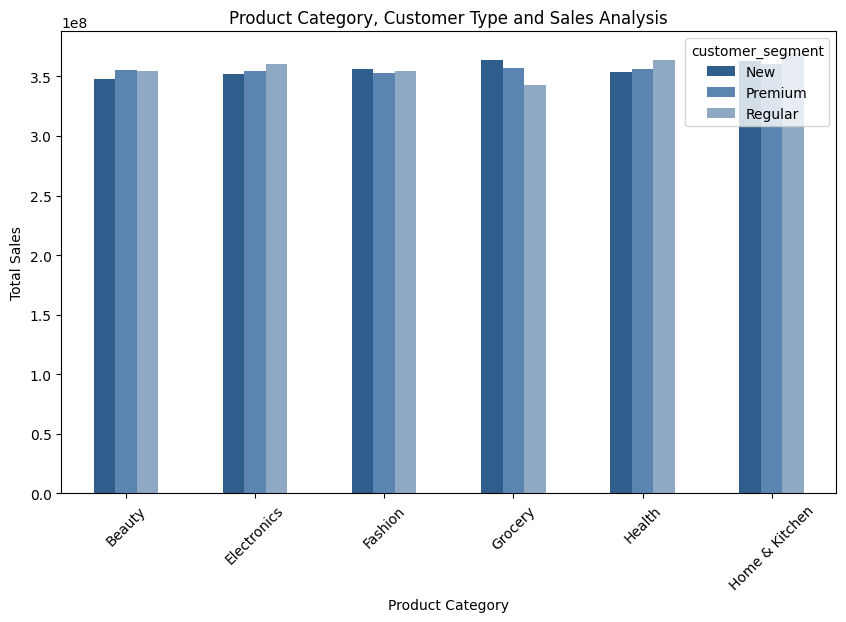

In [ ]:
category_customer = data.groupby(
    ['product_category', 'customer_segment']
)['final_price'].sum().unstack()

category_customer.plot(
    kind='bar',
    figsize=(10,6),
    color=['#2F5D8C', '#5B84B1', '#8FA9C4', '#B8C7D9']
)

plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.title('Product Category, Customer Type and Sales Analysis')
plt.xticks(rotation=45)
plt.show()

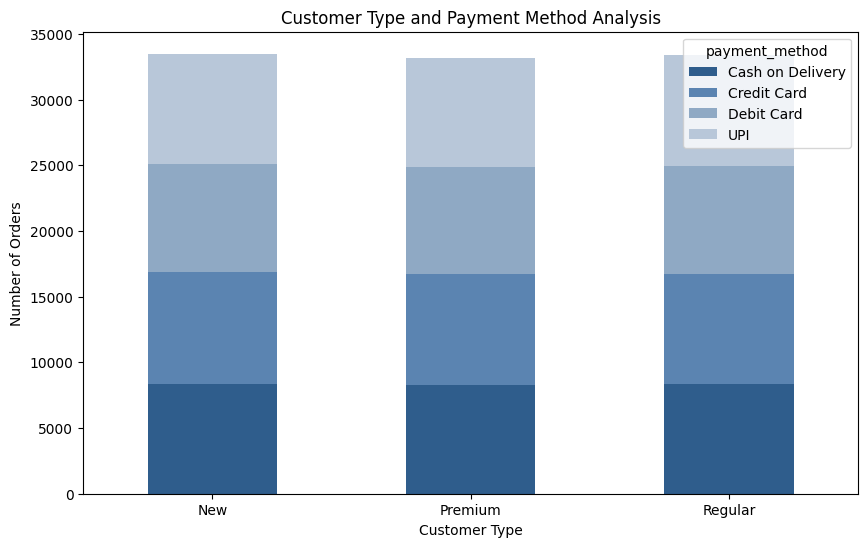

In [ ]:
payment_customer = data.groupby(
    ['customer_segment', 'payment_method']
)['order_id'].count().unstack()

payment_customer.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#2F5D8C', '#5B84B1', '#8FA9C4', '#B8C7D9']
)

plt.xlabel('Customer Type')
plt.ylabel('Number of Orders')
plt.title('Customer Type and Payment Method Analysis')
plt.xticks(rotation=0)
plt.show()

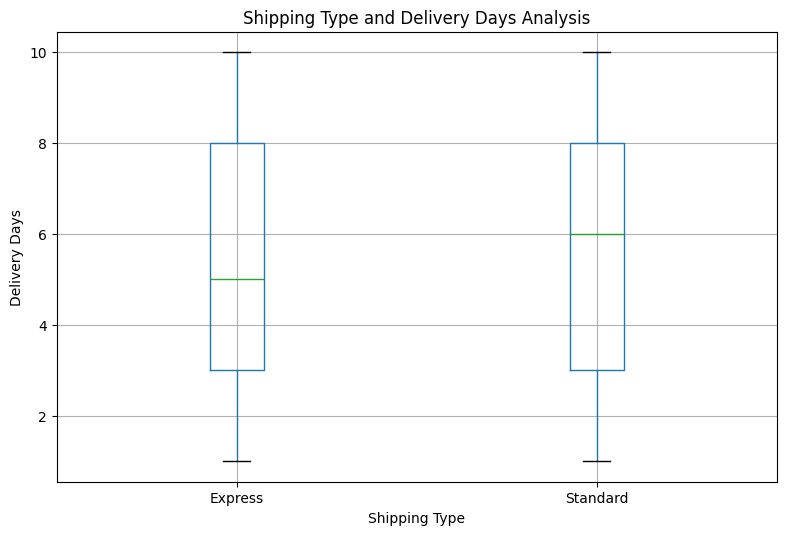

In [ ]:
data.boxplot(
    column='delivery_days',
    by='shipping_type',
    figsize=(9,6)
)

plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')
plt.title('Shipping Type and Delivery Days Analysis')
plt.suptitle('')
plt.show()

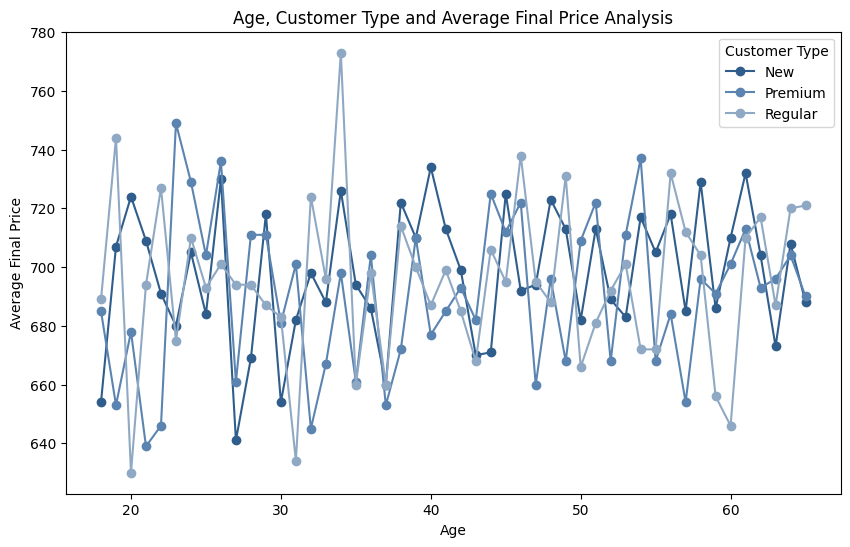

In [ ]:
age_customer = data.groupby(
    ['age', 'customer_segment']
)['final_price'].count().unstack()

age_customer.plot(
    kind='line',
    figsize=(10,6),
    marker='o',
    color=['#2F5D8C', '#5B84B1', '#8FA9C4', '#B8C7D9']
)

plt.xlabel('Age')
plt.ylabel('Average Final Price')
plt.title('Age, Customer Type and Average Final Price Analysis')
plt.legend(title='Customer Type')
plt.show()

**6. Outlier Analysis**

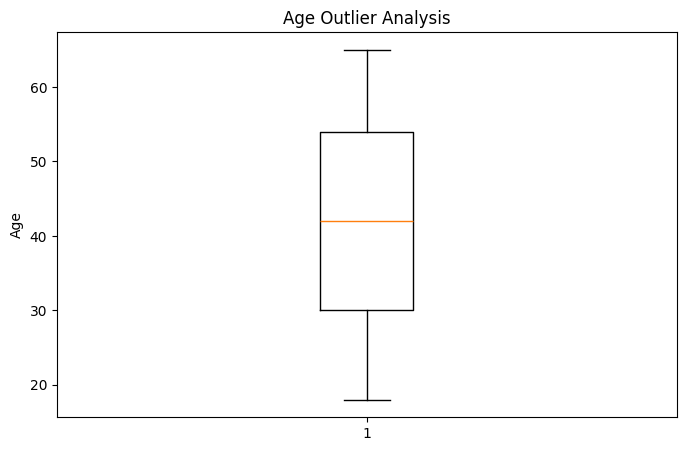

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(data['age'])

plt.ylabel('Age')
plt.title('Age Outlier Analysis')

plt.show()

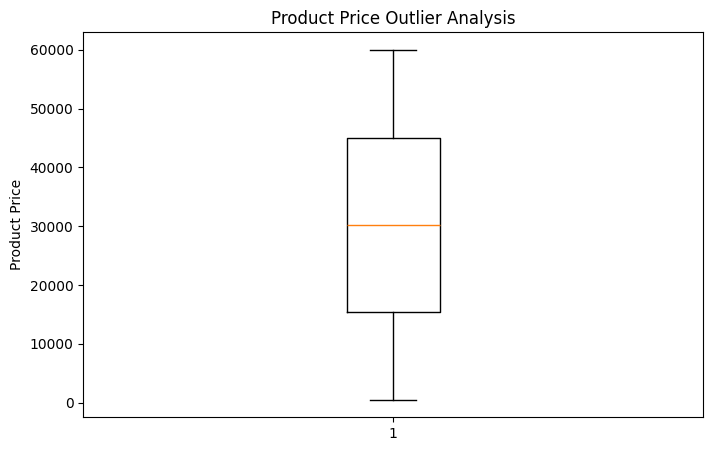

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(data['product_price'])

plt.ylabel('Product Price')
plt.title('Product Price Outlier Analysis')

plt.show()

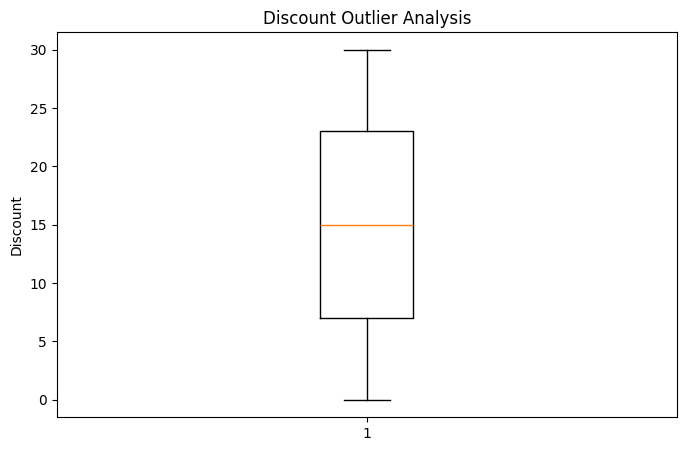

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(data['discount_percentage'])

plt.ylabel('Discount')
plt.title('Discount Outlier Analysis')

plt.show()

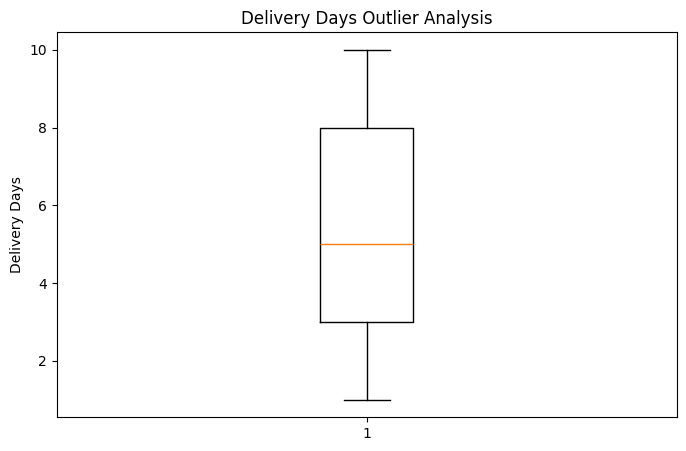

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(data['delivery_days'])

plt.ylabel('Delivery Days')
plt.title('Delivery Days Outlier Analysis')

plt.show()

**7. Correlation Analysis**

In [ ]:
correlation = data.corr(numeric_only=True)

print(correlation)

                          age  product_price  quantity  discount_percentage  \
age                  1.000000      -0.000814 -0.000129            -0.004035   
product_price       -0.000814       1.000000  0.000950            -0.002886   
quantity            -0.000129       0.000950  1.000000            -0.003579   
discount_percentage -0.004035      -0.002886 -0.003579             1.000000   
final_price         -0.000823       0.730757  0.575303            -0.137332   
delivery_days       -0.003954       0.001554  0.004017            -0.000453   

                     final_price  delivery_days  
age                    -0.000823      -0.003954  
product_price           0.730757       0.001554  
quantity                0.575303       0.004017  
discount_percentage    -0.137332      -0.000453  
final_price             1.000000       0.003789  
delivery_days           0.003789       1.000000  


**7. Correlation Analysis**

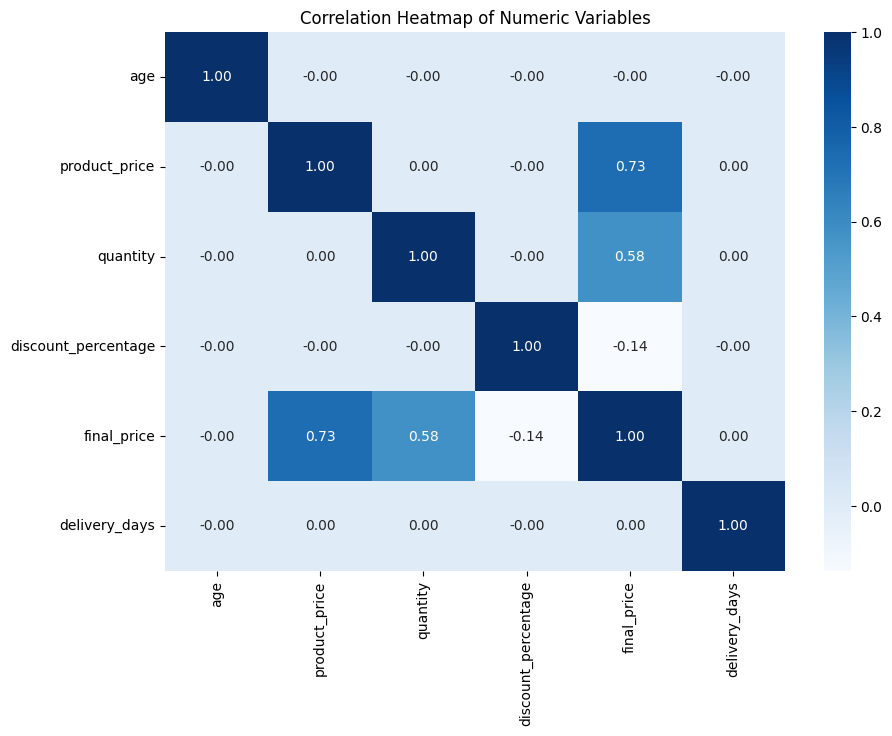

In [ ]:
import seaborn as sns


plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

**8. Skewness Analysis**

In [ ]:
skewness = data[
    ['age',
     'product_price',
     'quantity',
     'discount_percentage',
     'final_price',
     'delivery_days']
].skew()

print(skewness)

age                   -0.004988
product_price          0.003249
quantity              -0.003067
discount_percentage   -0.003597
final_price            0.934747
delivery_days          0.002270
dtype: float64


**9. Kurtosis Analysis**

In [ ]:
kurtosis = data[
    ['age',
     'product_price',
     'quantity',
     'discount_percentage',
     'final_price',
     'delivery_days']
].kurt()

print(kurtosis)

age                   -1.201172
product_price         -1.195106
quantity              -1.364612
discount_percentage   -1.201628
final_price            0.169047
delivery_days         -1.221514
dtype: float64


**10. Key Business Insights**
1. Home & Kitchen category generated the highest total sales value.

2. Product price has a strong positive relationship with final price.

3. Higher order quantity is generally associated with higher final price.

4. Final price has a moderate right-skewed distribution.

5. Some transactions have comparatively higher sales values.

6. Age has almost no linear relationship with final price.

7. Delivery days have almost no linear relationship with final price.

8. Customer types show different purchasing and payment patterns.

9. The dataset contains no missing values, making it suitable for further analysis.

10. Overall, product pricing and order quantity are more closely related to sales value than age or delivery duration.
